In [1]:
%load_ext autoreload
%autoreload 2
import os
print(os.getcwd())
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import pickle
from utils import reproducibility
batch_size = 256
reproducibility(2025)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
%load_ext autoreload
%autoreload 2
from data_process import generate_simulated_data_final

/home/hx/J/DADA/assay_upload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# generate_simulated_data

In [2]:
# source domain: GTEx
simudata_GTE, label_GTE = generate_simulated_data_final(
    sc_data="../data_review2/dat1_gtex_tissue_tpm_filter.txt",
    n=5000, samplenum=5000,
    random_state=1024,       
    simulate_ev_biology=True,
    packaging_sigma=1.2,     
    dropout_strength=2.0,   
    dispersion_shape=0.8)

# target domain: HPA
simudata_HPA, label_HPA = generate_simulated_data_final(
    sc_data="../data_review2/dat1_hpa_tissue_tpm_filter.txt",
        n=5000, samplenum=50,
    random_state=42,
    simulate_ev_biology=True,
    packaging_sigma=0.6,       
    dropout_strength=0.8,       
    dispersion_shape=2.5)


Reading single-cell dataset, this may take 1 min
Sampling cells and applying non-Gaussian transforms...


100%|██████████| 5000/5000 [03:46<00:00, 22.09it/s]
/home/hx/anaconda3/envs/dada/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Sampling is done. Data shape: (5000, 18757)
Reading single-cell dataset, this may take 1 min
Sampling cells and applying non-Gaussian transforms...


100%|██████████| 50/50 [00:01<00:00, 26.38it/s]

Sampling is done. Data shape: (50, 18757)



/home/hx/anaconda3/envs/dada/lib/python3.9/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# Split data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Scaling...
Using minmax scaler...
Scaling...
Using minmax scaler...
(5000, 18757)
(5000, 23)
(50, 18757)
(50, 23)
Scaling...
Using minmax scaler...
(664, 18757)


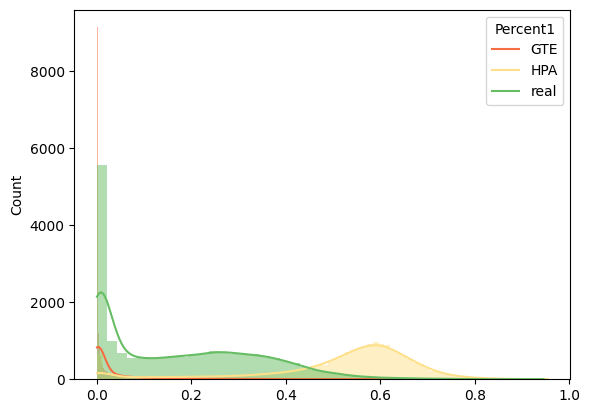

In [3]:
%load_ext autoreload
%autoreload 2
from data_process import GTEDataGeneVar, GetXandYSelG, GetXandYSelGReal, PlotData, DataSplitTrValTe

variance_threshold = 0.9
all_genename = GTEDataGeneVar(simudata_GTE, vart = False)
GTE_x, GTE_y, celltypes = GetXandYSelG(simudata_GTE, all_genename, scaler="mms") 
HPA_x, HPA_y, celltypes = GetXandYSelG(simudata_HPA, all_genename, scaler="mms") 
print(GTE_x.shape)
print(GTE_y.shape)
print(HPA_x.shape)
print(HPA_y.shape)

real_pth = "../data_review2/all_exo_tpm_filter.txt"
real_x = GetXandYSelGReal(real_pth, all_genename, scaler="mms") 
print(real_x.shape)
PlotData(GTE_x, HPA_x, real_x, per = 1)
GTE_x_train, GTE_x_val, GTE_x_test, GTE_y_train, GTE_y_val, GTE_y_test = DataSplitTrValTe(GTE_x, GTE_y)

# Save data

In [4]:
data_to_save = {

    'simudata_GTE': simudata_GTE,
    'label_GTE': list(label_GTE),
    'simudata_HPA': simudata_HPA,
    'label_HPA': list(label_HPA),

    'all_genename': all_genename,
    'celltypes': celltypes,

    'GTE_x': GTE_x,
    'GTE_y': GTE_y,
    'HPA_x': HPA_x,
    'HPA_y': HPA_y,
    'real_x': real_x,

    'GTE_x_train': GTE_x_train,
    'GTE_x_val': GTE_x_val,
    'GTE_x_test': GTE_x_test,
    'GTE_y_train': GTE_y_train,
    'GTE_y_val': GTE_y_val,
    'GTE_y_test': GTE_y_test,
}

with open(f'../result/Stim_data_sim.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)